 9. We will now consider the Boston housing data set, from the ISLP
 library.
 (a) Based on this data set, provide an estimate for the population
 mean of medv. Call this estimate ˆµ.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [3]:
boston = pd.read_csv(r'/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Textbook Dataset/ALL CSV FILES - 2nd Edition/Boston.csv', index_col=0)
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


 9. We will now consider the Boston housing data set, from the ISLP
 library.
 (a) Based on this data set, provide an estimate for the population
 mean of medv. Call this estimate ˆµ.
 (b) Provide an estimate of the standard error of ˆµ. Interpret this
 result.
 Hint: We can compute the standard error of the sample mean by
 dividing the sample standard deviation by the square root of the
 number of observations.

In [4]:
# sample mean = total x / sample size
# standard error = sample std / sqrt(sample size)

medv = boston.medv
mean = np.mean(medv)
se = np.std(medv) / len(medv)**0.5

mean, se

(np.float64(22.532806324110677), 0.4084569346972867)

 (c) Now estimate the standard error of ˆµ using the bootstrap. How
 does this compare to your answer from (b)?

In [5]:
import scipy.stats as stats


In [6]:


def boot_sample(df, col, func):
    sample = df.sample(frac=1, replace=True)
    return func(sample[col])

def boot(df, col, func, num_samples=1000):
    boot_results = []
    for i in range(num_samples):
        boot_results.append(boot_sample(df, col, func))
    return np.std(boot_results, axis=0)

boot_se = boot(boston, 'medv', np.mean)
boot_se


np.float64(0.41091581556228973)

The standard error value estimated by bootstrap method is really close to our previous estimation.

 (d) Based on your bootstrap estimate from (c), provide a 95% con
f
 idence interval for the mean of medv. Compare it to the results
 obtained by using Boston['medv'].std() and the two standard
 error rule (3.9).
 Hint: You can approximate a 95% confidence interval using the
 formula [ˆµ − 2SE(ˆµ), ˆµ + 2SE(ˆµ)].

In [7]:
lower_bound = mean - 2*boot_se
upper_bound = mean + 2*boot_se
[lower_bound, upper_bound]

[np.float64(21.7109746929861), np.float64(23.354637955235255)]

In [8]:
results = scipy.stats.ttest_1samp(medv, popmean=np.mean(medv))
results.confidence_interval()

ConfidenceInterval(low=np.float64(21.729528014578595), high=np.float64(23.33608463364276))

The confidence interval estimates are almost the same.

(e) Based on this data set, provide an estimate, ˆµmed, for the median
 value of medv in the population.

In [9]:
median = np.median(medv)
median

np.float64(21.2)

 (f) Wenowwouldlike to estimate the standard error of ˆµmed. Unfor
tunately, there is no simple formula for computing the standard
 error of the median. Instead, estimate the standard error of the
 median using the bootstrap. Comment on your findings.

In [10]:
boot_median_se = boot(boston, 'medv', np.median)
boot_median_se

np.float64(0.37453025244965166)

 (g) Based on this data set, provide an estimate for the tenth per
centile of medv in Boston census tracts. Call this quantity ˆµ0.1.
 (You can use the np.percentile() function.)

In [11]:
mu_10_quantile = np.quantile(medv, q=0.1)
mu_10_quantile

np.float64(12.75)

 (h) Use the bootstrap to estimate the standard error of ˆµ0.1. Com
ment on your findings.

In [12]:
from functools import partial
mu_01q_se = boot(boston, 'medv', partial(np.quantile, q=0.1))
mu_01q_se

np.float64(0.5062127122070325)

The mean of the tenth percentile is more variable compared to the mean of the median, as there are much fewer values in this small segment of the population.

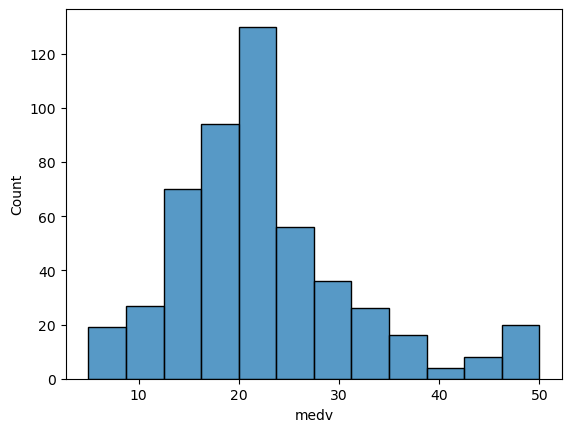

In [19]:
sns.histplot(x='medv', data=boston, bins=12)
plt.show()